In [1]:
import numpy as np
np.set_printoptions(threshold=np.inf)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import normflows as nf
import random
from torch.utils.data import DataLoader
import pandas as pd
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
import pyvinecopulib as pv

from scipy.stats import norm

from GPDFlow_S import S_mGPD_NF, ConditionalMaskedAffineFlow, ActNormConditional, ConditionalNormalizingFlow
import Common_Functions as cf
from matplotlib.colors import LinearSegmentedColormap
import scipy.stats as stats


Using device: cuda


#### Define a GPDFlow

In [2]:
dir_out = "/home/pgrad2/2448355h/My_PhD_Project/01_Output/GPDFlow/"

dim = 20


#### Find a suitable threshold for the simulated data

In [349]:
from scipy.stats import burr12

np.random.seed(42)
n_samples = 5000

# ── Burr XII marginal parameters ──────────────────────────────────────────────
# Burr XII CDF: F(x) = 1 - (1 + x^c)^{-k},  x > 0
# Tail index α = c*k  →  GPD shape γ ≈ 1/(c*k)
c_base = np.array([2.0, 3.0, 2.5, 1.5, 3.0])
k_base = np.array([1.5, 1.0, 2.0, 3.0, 3.5])
c_vals = np.tile(c_base, dim // len(c_base) + 1)[:dim]
k_vals = np.tile(k_base, dim // len(k_base) + 1)[:dim]

# ── AR(1) Student-t copula ───────────────────────────────────────────────────
# Correlation R[j, k] = rho^{|j-k|}.  Draw Y ~ multivariate-t(0, R, nu) and set
# U_j = t_nu(Y_j); the marginals of a t-copula are uniform by construction.
# Upper-tail dependence has the closed form
#   chi_{jk} = 2 * T_{nu+1}( -sqrt((nu+1)(1 - rho_{jk}) / (1 + rho_{jk})) ),
# which decays with the lag |j-k| (see the theoretical-chi cell below).
rho_t = 0.8          # AR(1) base correlation
nu_t  = 5            # t-copula degrees of freedom
R_t   = cf.ar1_correlation(dim, rho_t)

def simulate_t_copula(n, corr, nu, seed=42):
    Y = stats.multivariate_t(
        loc=np.zeros(corr.shape[0]), shape=corr, df=nu
    ).rvs(size=n, random_state=seed)
    return stats.t.cdf(Y, df=nu)          # shape (n, d) uniform on [0,1]

U = simulate_t_copula(n_samples, R_t, nu_t, seed=42)

# Apply Burr XII marginals via inverse CDF
samples_origin = np.column_stack([
    burr12.ppf(U[:, j], c=c_vals[j], d=k_vals[j]) for j in range(dim)
])
print(f"Generated {n_samples} samples  |  shape: {samples_origin.shape}")

# ── True GPD parameters at the 95th-percentile threshold (fitted on large sample) ──
# For Burr XII the excess above a high threshold converges to a GPD;
# we obtain the limiting (σ, γ) numerically from a large independent Burr sample.
thres_q = 0.97
n_fit   = 200_000
true_sigma, true_gamma = [], []
for j in range(dim):
    big = burr12.rvs(c=c_vals[j], d=k_vals[j], size=n_fit, random_state=j)
    u_j = burr12.ppf(thres_q, c=c_vals[j], d=k_vals[j])
    exc = big[big > u_j] - u_j
    g, _, s = stats.genpareto.fit(exc, floc=0)
    true_gamma.append(g)
    true_sigma.append(s)

sigma = torch.tensor(true_sigma, dtype=torch.float32)
gamma = torch.tensor(true_gamma, dtype=torch.float32)
print(f"sigma = {sigma.numpy().round(3)}")
print(f"gamma = {gamma.numpy().round(3)}")

if dim == 2:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(samples_origin[:, 0], samples_origin[:, 1], alpha=0.3, s=5, color='steelblue')
    ax.set_xlabel('$X_1$');  ax.set_ylabel('$X_2$')
    ax.set_title('AR(1) t-copula + Burr XII margins')
    plt.tight_layout();  plt.show()

Generated 5000 samples  |  shape: (5000, 20)
sigma = [1.118 1.07  0.445 0.547 0.181 1.096 1.067 0.435 0.555 0.171 1.137 1.073
 0.448 0.535 0.178 1.139 1.104 0.472 0.547 0.178]
gamma = [0.333 0.318 0.177 0.185 0.028 0.342 0.345 0.208 0.161 0.074 0.31  0.344
 0.159 0.202 0.023 0.325 0.315 0.145 0.191 0.033]


In [350]:
# ── Theoretical pairwise chi of the AR(1) t-copula ───────────────────────────
# chi_{jk} = 2 T_{nu+1}(-sqrt((nu+1)(1 - rho^{|j-k|}) / (1 + rho^{|j-k|}))).
chi_theo = cf.t_copula_pairwise_chi(R_t, nu_t)          # (dim, dim), diagonal 1
chi_emp  = cf.pairwise_chi_from_data(samples_origin, p=0.99)

print("lag | rho^lag | chi_theo (q->1) | chi_emp(q=0.99)")
for lag in (1, 2, 3, 5, 10):
    print(f"{lag:3d} | {rho_t**lag:7.4f} | {np.diag(chi_theo, lag).mean():15.4f} | "
          f"{np.diag(chi_emp, lag).mean():.4f}")
# Note: chi_theo is the q->1 limit, so the rank-based estimate at q=0.95 sits
# slightly above it (finite-level bias, expected for the t-copula).

lag | rho^lag | chi_theo (q->1) | chi_emp(q=0.99)
  1 |  0.8000 |          0.4454 | 0.5021
  2 |  0.6400 |          0.2948 | 0.3611
  3 |  0.5120 |          0.2134 | 0.2741
  5 |  0.3277 |          0.1319 | 0.1667
 10 |  0.1074 |          0.0702 | 0.1000


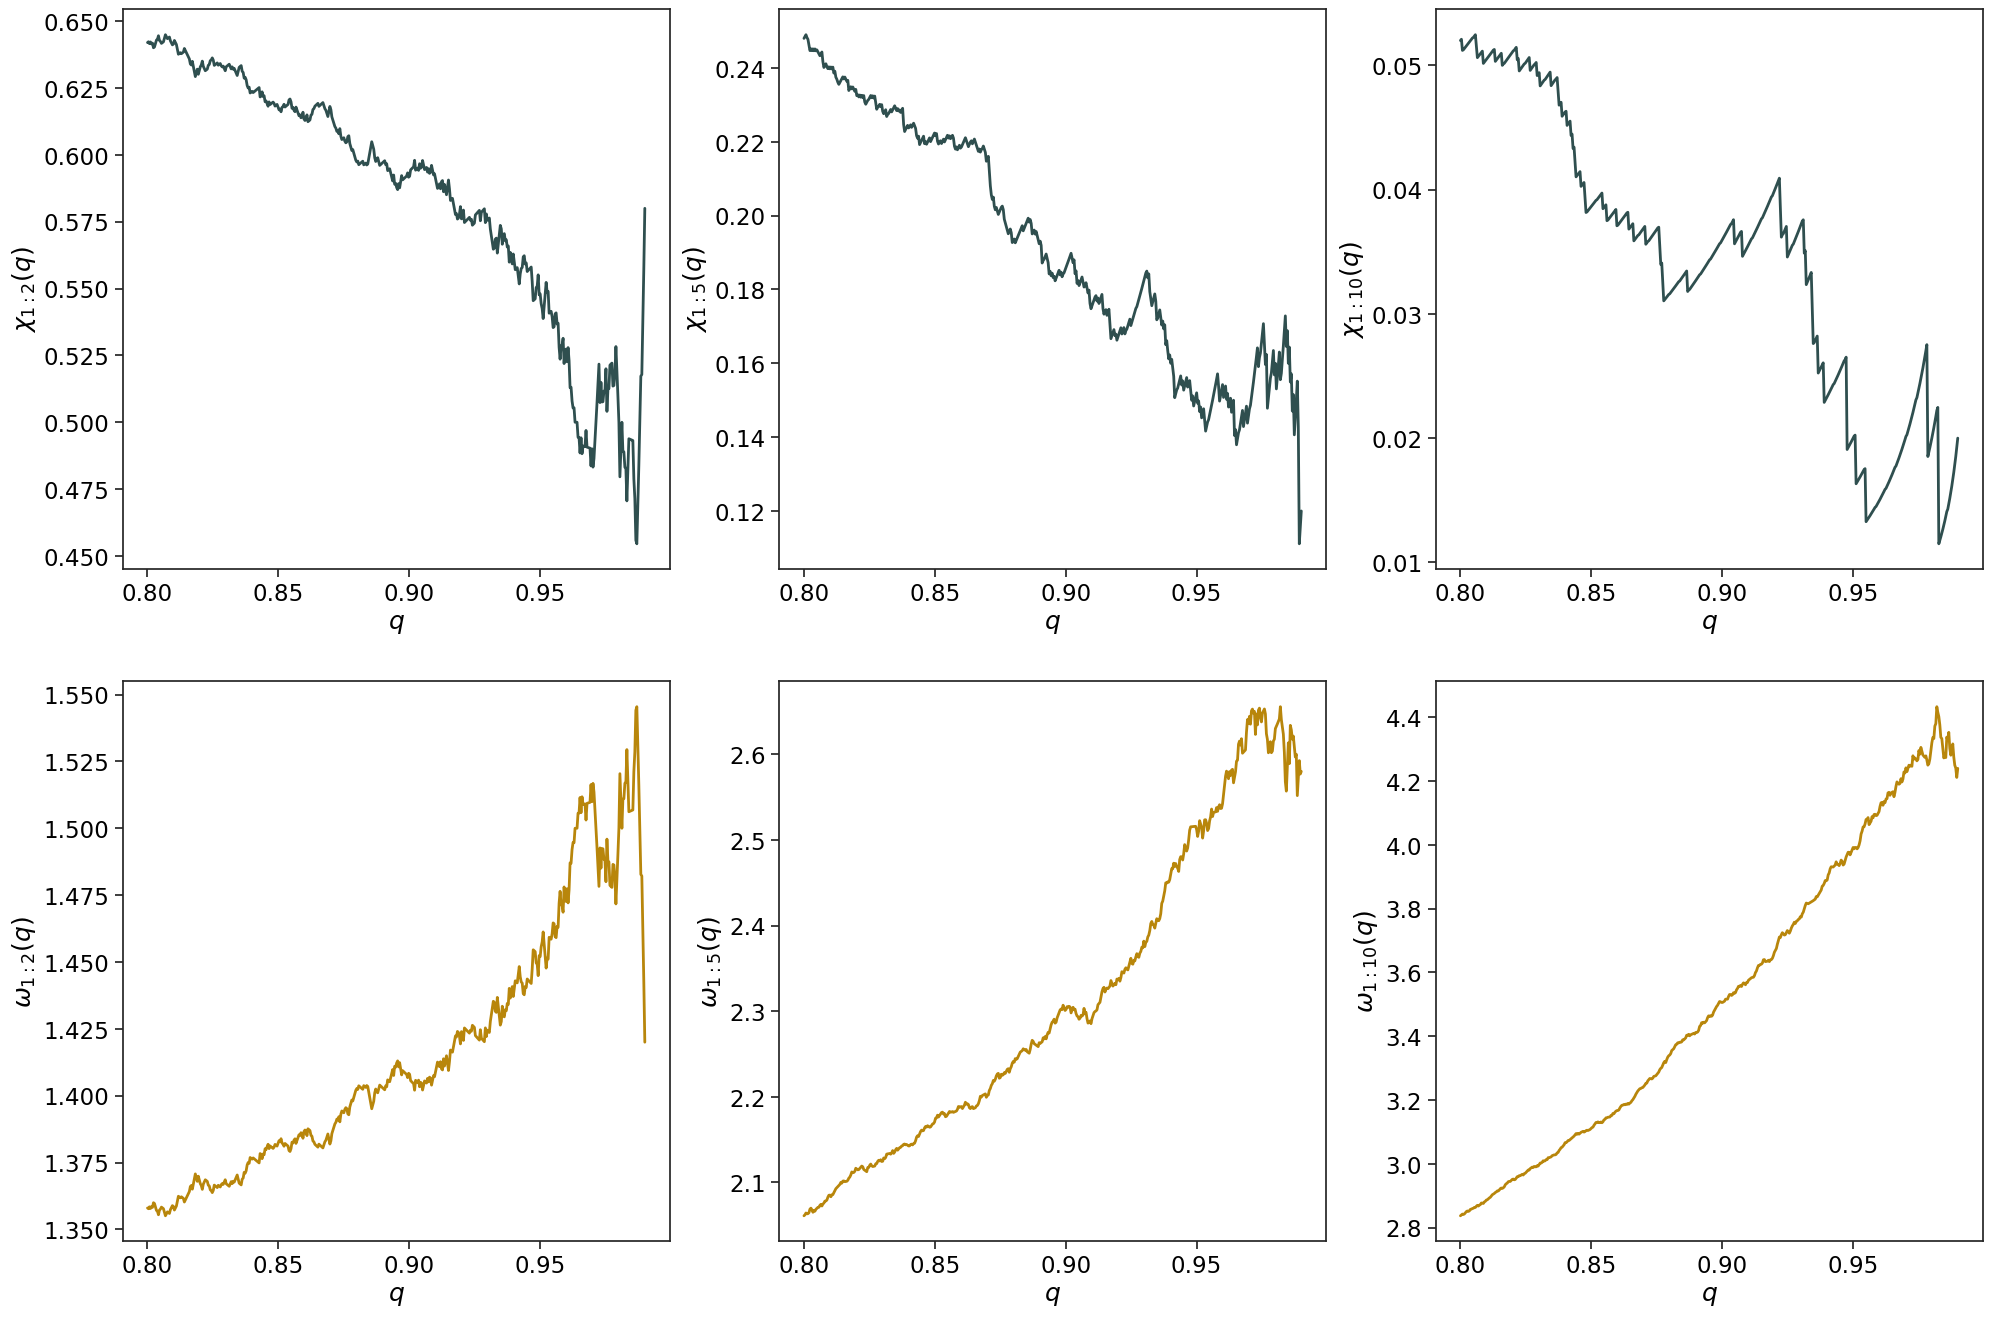

In [351]:
probs = np.linspace(0.8, 0.99, 500)
col_counts = [2, 5, 10]  # CHANGED: was 25 -- 22 columns after removing pegged currencies

chi_emp = {
    k: [cf.empirical_tail_dependence_measure(samples_origin[:, :k], p, 'and') for p in probs]
    for k in col_counts
}
omega_emp = {
    k: [cf.empirical_tail_dependence_measure(samples_origin[:, :k], p, 'or') for p in probs]
    for k in col_counts
}

# 2x3 grid: chi(q) on row 1, omega(q) on row 2, one column per subset size
sns.set(style="ticks", font_scale=1.5)
color_chi = 'darkslategray'
color_omega = 'darkgoldenrod'

fig, axes = plt.subplots(2, 3, figsize=(24, 16))

for col, k in enumerate(col_counts):
    ax = axes[0, col]
    ax.plot(probs, chi_emp[k], color=color_chi, linewidth=2)
    ax.set_xlabel(r'$q$', color='black')
    ax.set_ylabel(rf'$\chi_{{1:{k}}}(q)$', color='black')
    ax.tick_params(axis='both', labelcolor='black')

    ax = axes[1, col]
    ax.plot(probs, omega_emp[k], color=color_omega, linewidth=2)
    ax.set_xlabel(r'$q$', color='black')
    ax.set_ylabel(rf'$\omega_{{1:{k}}}(q)$', color='black')
    ax.tick_params(axis='both', labelcolor='black')


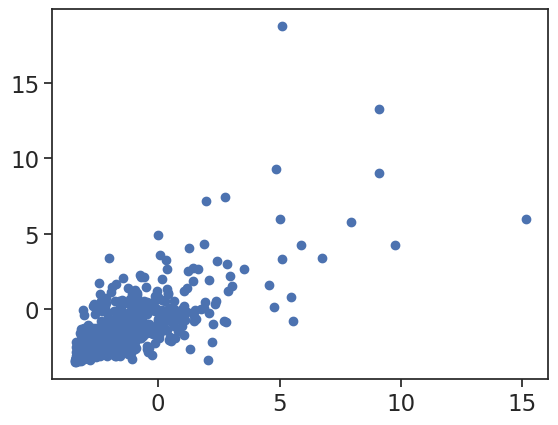

In [393]:
THRESHOLD_Q = 0.98

thres = np.quantile(samples_origin, THRESHOLD_Q, axis=0)

cond = np.any(samples_origin > thres, axis=1)
samples = samples_origin[cond,:]

thres = thres.reshape(1,-1)
samples = samples - thres

plt.scatter(samples[:,0],samples[:,1] )


In [394]:
samples.shape

(716, 20)

In [395]:
# --- 5-fold cross-validation setup ------------------------------------------
import importlib
import cv_utils
importlib.reload(cv_utils)
from cv_utils import (
    make_folds,
    run_cv_gpdflow_likelihood,
    run_cv_gpdflow_mmd,
    run_cv_flow_baseline,
    run_cv_parametric_mgpd,
    build_probit_copula,
)

SMOKE = False                     # set True for a fast top-to-bottom check
EPOCHS_LIK = 5 if SMOKE else 500
EPOCHS_MMD = 5 if SMOKE else 500
EPOCHS_BL  = 5 if SMOKE else 400
EPOCHS_PAR = 5 if SMOKE else 300
SIM_MULT   = 30                   # simulated rows per fold = SIM_MULT * |fold k|


In [396]:
folds = make_folds(len(samples), n_splits=5, seed=1234)
print('fold val sizes:', [len(v) for _, v in folds])

fold val sizes: [144, 143, 143, 143, 143]


In [397]:
# --- Likelihood-based GPDFlow, 5-fold cross-validation ---------------------
# For fold k: train on the other 4 folds, early-stop on fold k (patience 100 on
# the validation NLL), then draw SIM_MULT * |fold k| observations from the
# fold-k model.  cv_utils keeps the 5 out-of-fold blocks SEPARATE
# (`samples_simu_folds`, raw scale) and computes NO tail-dependence summary --
# chi / omega are formed here, so the evaluation threshold can be changed
# without refitting.
THRESHOLD_Q = 0.99

dim = samples.shape[1]
p_cluster = samples.shape[0] / samples_origin.shape[0]
p_sim_q = 1.0 - (1.0 - THRESHOLD_Q) / p_cluster    # cluster-conditional level matching q = THRESHOLD_Q

# Shared flow / penalty config: used by BOTH the CV below and the final
# full-data fit, so the two can never drift (arch = hparam-sweep winner L4/lsf3).
LIK_CFG = dict(
    num_layers=4, latent_size_factor=3,
    penalty_lambda=1e5, marg_lambda=500,
    seed=1234,
)


def cv_pairwise_chi(fold_blocks, p):
    """Mean over CV folds of each fold model's rank-based pairwise chi at level p
    (folds are NOT pooled -- a pool of 5 separately fitted flows is a mixture)."""
    return np.mean([cf.pairwise_chi_from_data(b, p=p) for b in fold_blocks], axis=0)


def cv_pairwise_omega(fold_blocks, p):
    return np.mean([cf.pairwise_omega_from_data(b, p=p) for b in fold_blocks], axis=0)


cv_like = run_cv_gpdflow_likelihood(
    samples, folds, device, thres,
    epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
    patience=100, **LIK_CFG,
    init_from_gpd= True
)

print('p_cluster =', round(p_cluster, 4), ' p_sim_q =', round(p_sim_q, 4))
print('per-fold best val NLL :', np.round(cv_like['best_vals'], 4))
print('per-fold best epoch   :', [h['best_epoch'] for h in cv_like['hist']])
print('fold-mean sigma_hat   :', np.round(cv_like['sigma_hat'], 3))
print('fold-mean gamma_hat   :', np.round(cv_like['gamma_hat'], 3))


[likelihood] fold 1/5 (train 572, val 144)


  scipy margin init  gamma~[ 0.216  0.404  0.36   0.228 -0.003  0.236  0.257 -0.016  0.075 -0.121
  0.397  0.385  0.201  0.204 -0.006  0.245  0.237  0.167  0.572 -0.003]
  scipy margin init  sigma~[1.317 1.201 0.456 0.609 0.195 1.479 1.402 0.678 0.591 0.201 0.919 1.065
 0.542 0.598 0.175 1.25  1.554 0.504 0.359 0.179]
  epoch    1/500 | train=17685.2770 | val=14030.7207 | val_nll=27.2323
  epoch   25/500 | train=375.2234 | val=355.9193 | val_nll=21.8859
  epoch   50/500 | train=367.5388 | val=354.2400 | val_nll=21.3114
  epoch   75/500 | train=365.6769 | val=354.6476 | val_nll=21.7942
  epoch  100/500 | train=369.4807 | val=355.7934 | val_nll=23.0042
  epoch  125/500 | train=369.5840 | val=357.6361 | val_nll=25.6067
  early stopping at epoch 138 (best val NLL @ 38).
[likelihood] fold 2/5 (train 573, val 143)
  scipy margin init  gamma~[ 0.299  0.365  0.473  0.254 -0.042  0.252  0.251  0.086  0.064 -0.141
  0.246  0.298  0.279  0.214 -0.059  0.145  0.342  0.129  0.53  -0.002]
  scipy ma

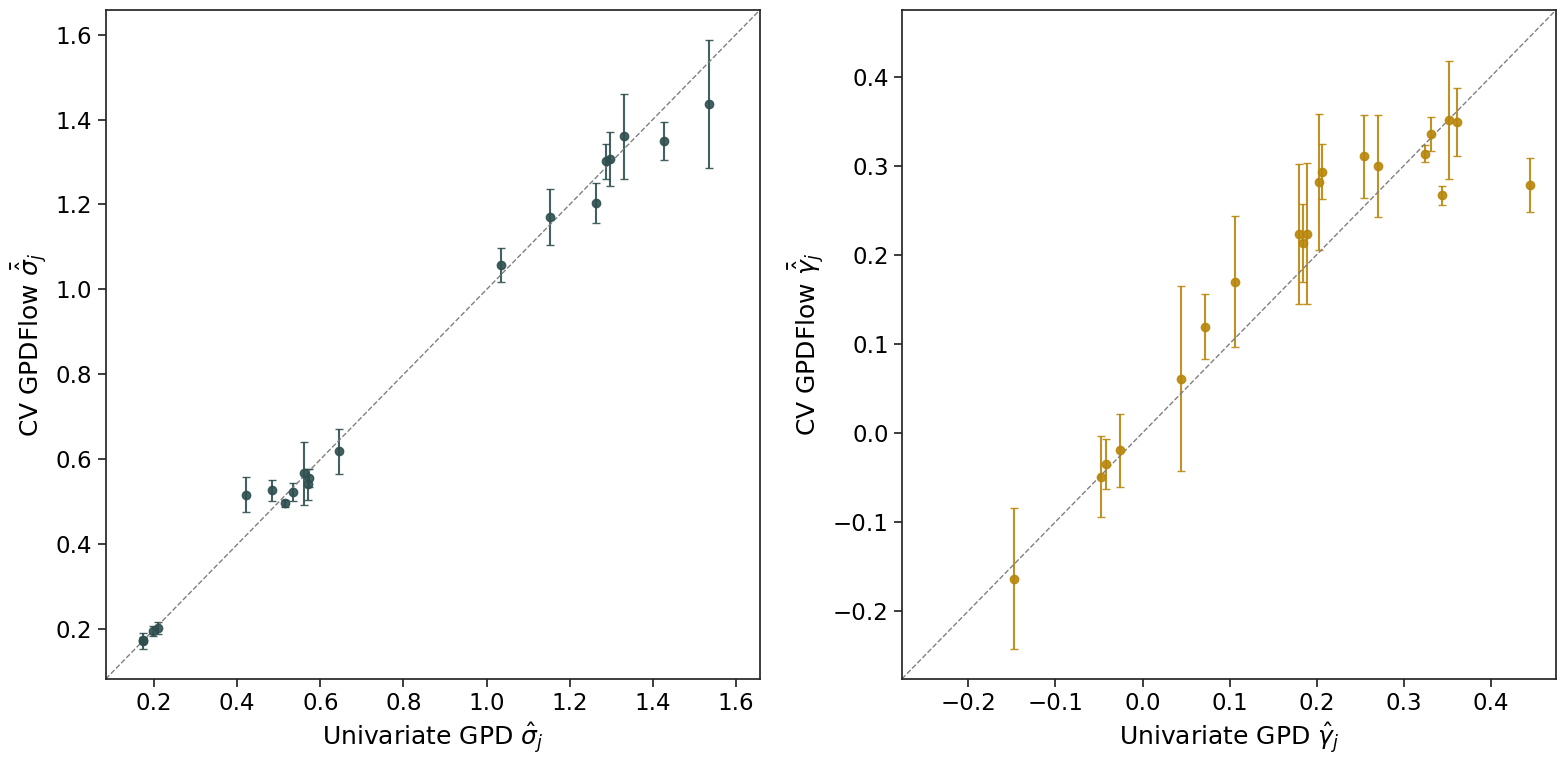

In [398]:
sigma_hat = cv_like['sigma_hat']
gamma_hat = cv_like['gamma_hat']
sigma_hat_folds = cv_like['sigma_hat_folds']
gamma_hat_folds = cv_like['gamma_hat_folds']

uni_sigmas = []
uni_gammas = []
for i in range(dim):
    data_i = samples[samples[:, i] > 0, i]
    c, loc, scale = stats.genpareto.fit(data_i, floc=0)
    uni_gammas.append(c)
    uni_sigmas.append(scale)
uni_sigmas = np.array(uni_sigmas)
uni_gammas = np.array(uni_gammas)

sns.set(style="ticks", font_scale=1.5)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

ax = axes[0]
ax.errorbar(uni_sigmas, sigma_hat, yerr=sigma_hat_folds.std(axis=0),
            fmt='o', color='darkslategray', ecolor='darkslategray',
            alpha=0.9, capsize=3)
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Univariate GPD $\hat{\sigma}_j$', color='black')
ax.set_ylabel(r'CV GPDFlow $\bar{\hat{\sigma}}_j$', color='black')
ax.tick_params(axis='both', labelcolor='black')

ax = axes[1]
ax.errorbar(uni_gammas, gamma_hat, yerr=gamma_hat_folds.std(axis=0),
            fmt='o', color='darkgoldenrod', ecolor='darkgoldenrod',
            alpha=0.9, capsize=3)
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Univariate GPD $\hat{\gamma}_j$', color='black')
ax.set_ylabel(r'CV GPDFlow $\bar{\hat{\gamma}}_j$', color='black')
ax.tick_params(axis='both', labelcolor='black')

fig.tight_layout()
plt.show()

p_sim_q          : 0.9302
RMSE chi         : 0.1254
TDE  chi         : 0.1190
mean signed bias : +0.1190


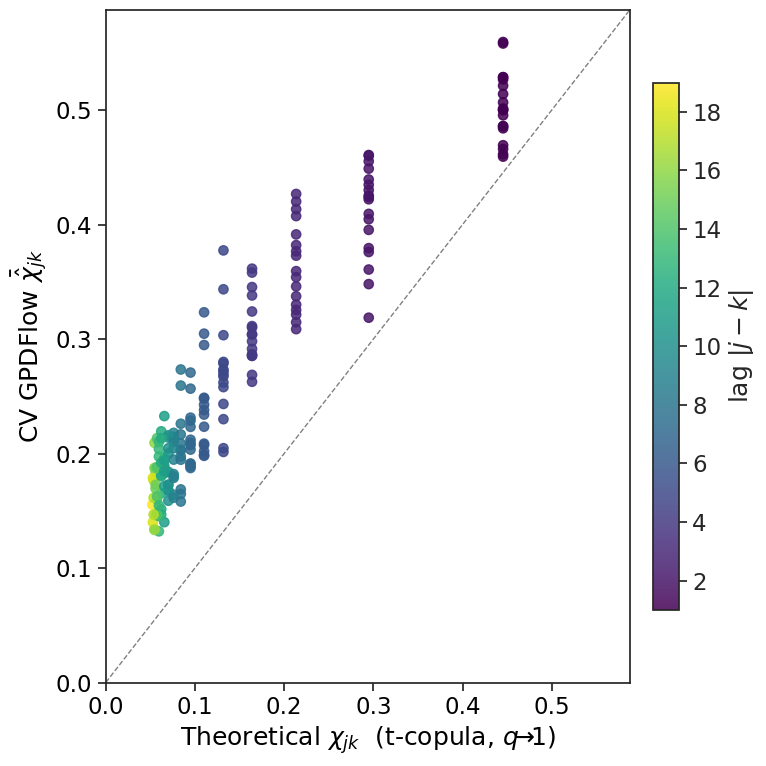

In [399]:
# --- Estimated vs theoretical pairwise chi ------------------------------------
# Estimated chi = mean over the 5 CV fold models of each fold's rank-based
# pairwise chi of its simulated draws (folds NOT pooled -- a pool of 5 flows is a
# mixture, not an mGPD), evaluated at the cluster-conditional level p_sim_q.
# Theoretical chi = AR(1) t-copula closed form (the q -> 1 limit).

chi_hat_mat  = cv_pairwise_chi(cv_like['samples_simu_folds'], p_sim_q)   # (dim, dim)
chi_theo_mat = cf.t_copula_pairwise_chi(R_t, nu_t)                       # (dim, dim)

iu = np.triu_indices(dim, k=1)
chi_hat_pairs  = chi_hat_mat[iu]
chi_theo_pairs = chi_theo_mat[iu]
lag_pairs      = iu[1] - iu[0]                                           # |j - k|

print(f'p_sim_q          : {p_sim_q:.4f}')
print(f'RMSE chi         : {cf.rmse_chi(chi_hat_pairs, chi_theo_pairs):.4f}')
print(f'TDE  chi         : {cf.tde_chi(chi_hat_mat, chi_theo_mat):.4f}')
print(f'mean signed bias : {(chi_hat_pairs - chi_theo_pairs).mean():+.4f}')

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(chi_theo_pairs, chi_hat_pairs, c=lag_pairs, cmap='viridis',
                alpha=0.85, s=45)
lims = [0.0, max(chi_theo_pairs.max(), chi_hat_pairs.max()) * 1.05]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Theoretical $\chi_{jk}$  (t-copula, $q\!\to\!1$)', color='black')
ax.set_ylabel(r'CV GPDFlow $\bar{\hat{\chi}}_{jk}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r'lag $|j-k|$')

fig.tight_layout()
plt.show()

#### MMD based estimation

In [405]:
MMD_CFG = dict(
    warmup_epochs=50, min_delta=1e-3,
    penalty_lambda=1e4, mmd_lambda=15, mmd_samples_per_face=128,
    mmd_censor_c=0, mmd_censor_tau=0.05,
    mmd_indicator_alpha=10, mmd_indicator_rho=3,
    num_layers=4, latent_size_factor=2,
    seed=1234,
)

cv_mmd = run_cv_gpdflow_mmd(
    samples, folds, device, thres,
    epochs=EPOCHS_MMD, samples_multiplier=SIM_MULT,
    patience=100, **MMD_CFG,
)
dim_2s = cv_mmd['dim_2s']

print('per-fold best val loss :', np.round(cv_mmd['best_vals'], 4))
print('per-fold best epoch    :', [h['best_epoch'] for h in cv_mmd['hist']])
print('dropped train rows/fold:', cv_mmd['dropped_rows_train'])
print('dropped val rows/fold  :', cv_mmd['dropped_rows_val'])


[mmd] fold 1/5 (train 572/572, val 144/144)
  epoch    1/500 | train=21.6912 | val=16.6447
  epoch   25/500 | train=0.4860 | val=1.4237
  epoch   50/500 | train=0.1888 | val=1.0217
  epoch   75/500 | train=0.2033 | val=1.0670
  epoch  100/500 | train=0.0921 | val=0.7839
  epoch  125/500 | train=0.0134 | val=0.5276
  epoch  150/500 | train=-0.1168 | val=0.6907
  epoch  175/500 | train=0.0769 | val=0.4376
  epoch  200/500 | train=-0.0329 | val=0.5337
  epoch  225/500 | train=-0.0594 | val=0.6534
  epoch  250/500 | train=-0.0804 | val=0.7704
  epoch  275/500 | train=-0.0605 | val=0.7190
  epoch  300/500 | train=-0.1671 | val=0.6037
  epoch  325/500 | train=-0.1139 | val=0.5022
  epoch  350/500 | train=-0.1570 | val=0.6046
  early stopping at epoch 352 (best val loss @ 252).
[mmd] fold 2/5 (train 573/573, val 143/143)
  epoch    1/500 | train=20.1568 | val=22.7489
  epoch   25/500 | train=0.4939 | val=0.5440
  epoch   50/500 | train=0.2542 | val=0.3679
  epoch   75/500 | train=0.3700 | val

p_sim_q          : 0.9302
RMSE chi         : 0.0631
TDE  chi         : 0.0564
mean signed bias : +0.0442


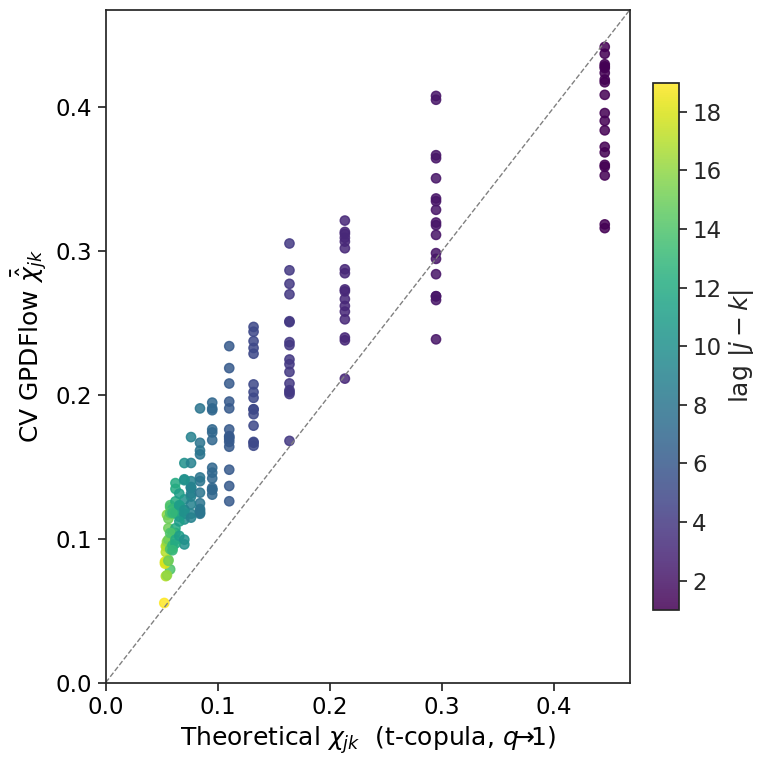

In [406]:
chi_hat_mat  = cv_pairwise_chi(cv_mmd['samples_simu_2s_folds'], p_sim_q)   # (dim, dim)
chi_theo_mat = cf.t_copula_pairwise_chi(R_t, nu_t)                       # (dim, dim)

iu = np.triu_indices(dim, k=1)
chi_hat_pairs  = chi_hat_mat[iu]
chi_theo_pairs = chi_theo_mat[iu]
lag_pairs      = iu[1] - iu[0]                                           # |j - k|

print(f'p_sim_q          : {p_sim_q:.4f}')
print(f'RMSE chi         : {cf.rmse_chi(chi_hat_pairs, chi_theo_pairs):.4f}')
print(f'TDE  chi         : {cf.tde_chi(chi_hat_mat, chi_theo_mat):.4f}')
print(f'mean signed bias : {(chi_hat_pairs - chi_theo_pairs).mean():+.4f}')

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(chi_theo_pairs, chi_hat_pairs, c=lag_pairs, cmap='viridis',
                alpha=0.85, s=45)
lims = [0.0, max(chi_theo_pairs.max(), chi_hat_pairs.max()) * 1.05]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Theoretical $\chi_{jk}$  (t-copula, $q\!\to\!1$)', color='black')
ax.set_ylabel(r'CV GPDFlow $\bar{\hat{\chi}}_{jk}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r'lag $|j-k|$')

fig.tight_layout()
plt.show()

In [366]:
BL_CFG = dict(warmup=20, seed=0)

cv_bl = run_cv_flow_baseline(
    samples, folds, device, thres,
    epochs=EPOCHS_BL, samples_multiplier=SIM_MULT,
    patience=40, **BL_CFG,
)
flow_baseline = cv_bl['models'][-1]              # last fold's flow, for the diagnostics below
print('per-fold best val NLL:', np.round(cv_bl['best_vals'], 4))
print('per-fold best epoch  :', [h['best_epoch'] for h in cv_bl['hist']])

[baseline] fold 1/5 (train 808, val 203)
  epoch    1/400 | train_nll=28.729 | val_nll=28.589
  epoch   25/400 | train_nll=20.153 | val_nll=20.778
  epoch   50/400 | train_nll=18.978 | val_nll=20.296
  epoch   75/400 | train_nll=18.447 | val_nll=20.141
  epoch  100/400 | train_nll=18.002 | val_nll=20.176
  early stopping at epoch 123 (best val NLL @ 83).
[baseline] fold 2/5 (train 809, val 202)
  epoch    1/400 | train_nll=28.795 | val_nll=28.615
  epoch   25/400 | train_nll=20.094 | val_nll=20.976
  epoch   50/400 | train_nll=19.068 | val_nll=20.811
  epoch   75/400 | train_nll=18.362 | val_nll=20.851
  early stopping at epoch 86 (best val NLL @ 46).
[baseline] fold 3/5 (train 809, val 202)
  epoch    1/400 | train_nll=28.676 | val_nll=28.000
  epoch   25/400 | train_nll=19.985 | val_nll=21.104
  epoch   50/400 | train_nll=18.888 | val_nll=20.844
  epoch   75/400 | train_nll=18.236 | val_nll=20.741
  epoch  100/400 | train_nll=17.739 | val_nll=20.967
  early stopping at epoch 119 (bes

p_sim_q          : 0.9505
RMSE chi         : 0.0503
TDE  chi         : 0.0433
mean signed bias : -0.0432


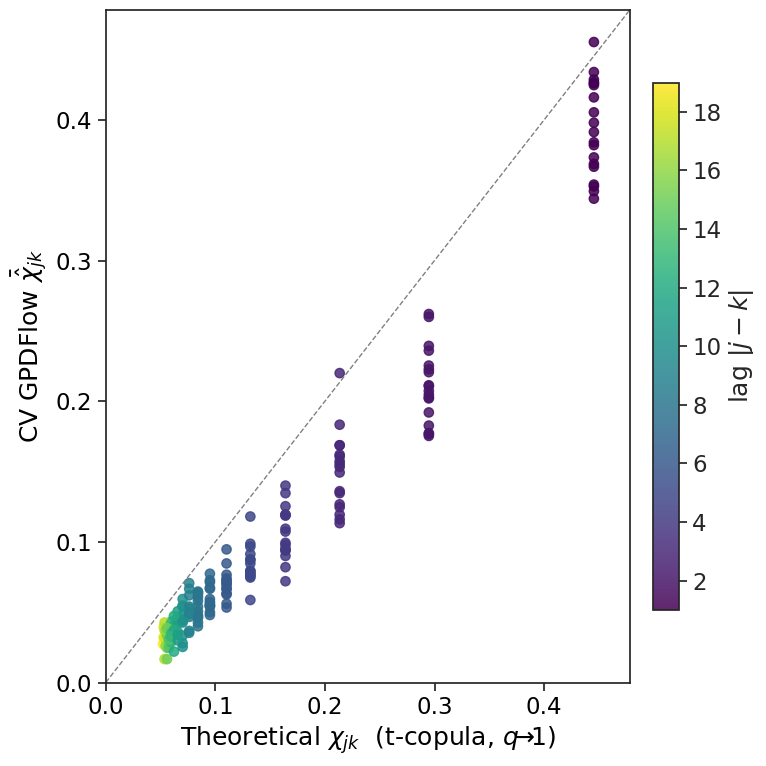

In [367]:
chi_hat_mat  = cv_pairwise_chi(cv_bl['samples_simu_bl_folds'], p_sim_q)   # (dim, dim)
chi_theo_mat = cf.t_copula_pairwise_chi(R_t, nu_t)                       # (dim, dim)

iu = np.triu_indices(dim, k=1)
chi_hat_pairs  = chi_hat_mat[iu]
chi_theo_pairs = chi_theo_mat[iu]
lag_pairs      = iu[1] - iu[0]                                           # |j - k|

print(f'p_sim_q          : {p_sim_q:.4f}')
print(f'RMSE chi         : {cf.rmse_chi(chi_hat_pairs, chi_theo_pairs):.4f}')
print(f'TDE  chi         : {cf.tde_chi(chi_hat_mat, chi_theo_mat):.4f}')
print(f'mean signed bias : {(chi_hat_pairs - chi_theo_pairs).mean():+.4f}')

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(chi_theo_pairs, chi_hat_pairs, c=lag_pairs, cmap='viridis',
                alpha=0.85, s=45)
lims = [0.0, max(chi_theo_pairs.max(), chi_hat_pairs.max()) * 1.05]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Theoretical $\chi_{jk}$  (t-copula, $q\!\to\!1$)', color='black')
ax.set_ylabel(r'CV GPDFlow $\bar{\hat{\chi}}_{jk}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r'lag $|j-k|$')

fig.tight_layout()
plt.show()

### Parametric mGPD 

In [368]:
import importlib
import parametric_mGPD
importlib.reload(parametric_mGPD)  # pick up edits without a kernel restart
from parametric_mGPD import (
    ParametricMGPD,
    GENERATORS,
    fit_parametric_mgpd,
    support_mask,
)


In [369]:
PAR_CFG = dict(generator='gaussian', seed=1234)

cv_par = run_cv_parametric_mgpd(
    samples, folds, device, thres,
    epochs=EPOCHS_PAR, samples_multiplier=SIM_MULT, **PAR_CFG,
)
print('per-fold best val NLL [par]:', np.round(cv_par['best_vals'], 4))
print('per-fold best epoch   [par]:', [h['best_epoch'] for h in cv_par['hist']])

chi_true_par = cf.pairwise_chi_from_data(samples_origin, p=THRESHOLD_Q)
chi_hat_par_cv = cv_pairwise_chi(cv_par['samples_simu_par_folds'], p_sim_q)
print('Traditional mGPD   tde_chi (CV):',
      round(cf.tde_chi(chi_hat_par_cv, chi_true_par), 4))

[parametric:gaussian] fold 1/5 (train 808, val 203)


  [gaussian  ] ep   0  batch loss    899.716   val NLL    41.067   (best    41.067)
  [gaussian  ] ep  50  batch loss     10.419   val NLL    11.398   (best    11.382)
  [gaussian  ] ep 100  batch loss     11.499   val NLL    11.332   (best    11.294)
  [gaussian  ] ep 149  batch loss     10.673   val NLL    11.284   (best    11.272)
[parametric:gaussian] fold 2/5 (train 809, val 202)
  [gaussian  ] ep   0  batch loss   1897.248   val NLL    46.393   (best    46.393)
  [gaussian  ] ep  50  batch loss      9.435   val NLL    12.302   (best    12.302)
  [gaussian  ] ep 100  batch loss     11.963   val NLL    12.245   (best    12.209)
  [gaussian  ] ep 150  batch loss     14.251   val NLL    12.217   (best    12.184)
  [gaussian  ] ep 192  batch loss     11.836   val NLL    12.192   (best    12.163)
[parametric:gaussian] fold 3/5 (train 809, val 202)
  [gaussian  ] ep   0  batch loss     41.593   val NLL    31.884   (best    31.884)
  [gaussian  ] ep  50  batch loss     11.961   val NLL  

p_sim_q          : 0.9505
RMSE chi         : 0.1321
TDE  chi         : 0.1268
mean signed bias : +0.1268


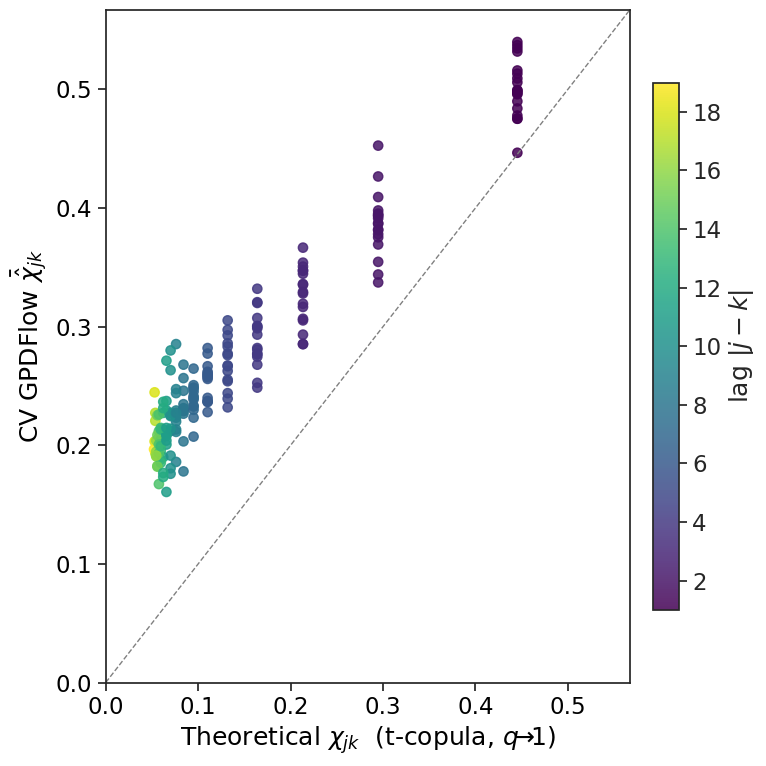

In [370]:
chi_hat_mat  = cv_pairwise_chi(cv_par['samples_simu_par_folds'], p_sim_q)   # (dim, dim)
chi_theo_mat = cf.t_copula_pairwise_chi(R_t, nu_t)                       # (dim, dim)

iu = np.triu_indices(dim, k=1)
chi_hat_pairs  = chi_hat_mat[iu]
chi_theo_pairs = chi_theo_mat[iu]
lag_pairs      = iu[1] - iu[0]                                           # |j - k|

print(f'p_sim_q          : {p_sim_q:.4f}')
print(f'RMSE chi         : {cf.rmse_chi(chi_hat_pairs, chi_theo_pairs):.4f}')
print(f'TDE  chi         : {cf.tde_chi(chi_hat_mat, chi_theo_mat):.4f}')
print(f'mean signed bias : {(chi_hat_pairs - chi_theo_pairs).mean():+.4f}')

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(chi_theo_pairs, chi_hat_pairs, c=lag_pairs, cmap='viridis',
                alpha=0.85, s=45)
lims = [0.0, max(chi_theo_pairs.max(), chi_hat_pairs.max()) * 1.05]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Theoretical $\chi_{jk}$  (t-copula, $q\!\to\!1$)', color='black')
ax.set_ylabel(r'CV GPDFlow $\bar{\hat{\chi}}_{jk}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r'lag $|j-k|$')

fig.tight_layout()
plt.show()

#### Monte Carlo simulation study: bias and variance of the CV estimators

`run_simulation_study_2` repeats the AR(1) t-copula + Burr XII DGP above, and for each generated
sample forms the threshold-exceedance set (rows with **at least one** component above its
per-margin empirical `threshold`-quantile), then refits the likelihood-based GPDFlow by 5-fold CV
on the excess data. Every round it stores the aggregated CV estimators &mdash; the fold-mean
marginal parameters $\hat\sigma$, $\hat\gamma$ and the fold-mean rank-based pairwise $\hat\chi$
(evaluated at the cluster-conditional level $p_{\text{sim}} = 1 - (1-q_\chi)/p_{\text{cluster}}$).

The RMSE targets are analytic: $\chi$ from the t-copula closed form
`cf.t_copula_pairwise_chi(R, nu)` (the $q\to1$ limit, per pair), and $(\sigma,\gamma)$ from the
**exact conditional-excess GPD parameters of the Burr XII margin** at level $q$ &mdash; the
reciprocal-hazard / von Mises parameterisation $\sigma(u)=S(u)/f(u)$, $\gamma(u)=[S/f]'(u)$
(`burr12_excess_gpd_params`, no GPD fitting). Runtime &asymp; `n_sim` &times; one 5-fold CV.


In [36]:
THRESHOLD_Q

0.97

In [9]:
# --- Repeat DGP + threshold-exceedance CV fit over N rounds, then MC RMSE vs truth ---
from cv_utils import run_simulation_study_2, summarize_simulation_study_2

N_SIM = 10

LIK_CFG = dict(
    num_layers=4, latent_size_factor=3,
    penalty_lambda=1e4, marg_lambda=300,
    seed=1234,
)

THRESHOLD_Q = 0.97


study2 = run_simulation_study_2(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    threshold=THRESHOLD_Q,                          # scalar quantile level q
    sim_kwargs=dict(n_samples=n_samples, dim=dim, rho=rho_t, nu=nu_t),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG),
    init_from_gpd=False,
    n_splits=5, fold_seed=1234, chi_q=0.99,
    verbose=False,
)

summary_df2, summary2 = summarize_simulation_study_2(study2)

print('p_cluster (per round):', np.round(study2['p_cluster'], 4))
print('p_sim     (per round):', np.round(study2['p_sim'], 4))
print()
print(f'RMSE sigma : {summary_df2.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df2.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df2.loc["chi", "rmse"]:.4f}')
print()
print(summary_df2[['mean_est', 'mean_bias', 'mean_variance', 'rmse']])


p_cluster (per round): [0.2346 0.2325 0.2342 0.2327 0.2332 0.2366 0.2372 0.2326 0.2361 0.2357]
p_sim     (per round): [0.9574 0.957  0.9573 0.957  0.9571 0.9577 0.9578 0.957  0.9576 0.9576]

RMSE sigma : 0.0453
RMSE gamma : 0.0941
RMSE chi   : 0.1145

       mean_est  mean_bias  mean_variance      rmse
sigma  0.645651  -0.035198       0.000632  0.045268
gamma  0.265985   0.085099       0.000275  0.094113
chi    0.225986   0.112931       0.000117  0.114505


In [10]:
study2

{'sigma_hat': array([[1.05608153, 1.0163703 , 0.39750972, 0.4941074 , 0.17143404,
         1.10978627, 1.09200251, 0.41336003, 0.47672844, 0.16468446,
         1.04228663, 1.1041491 , 0.41825122, 0.50205785, 0.16698186,
         1.08851945, 1.04091549, 0.4034152 , 0.48289257, 0.15332624],
        [1.03423297, 1.1002872 , 0.41560611, 0.46792811, 0.15852116,
         1.06215346, 1.04893231, 0.41614428, 0.50803119, 0.16354701,
         1.15141404, 1.05596232, 0.44350499, 0.49516997, 0.17681673,
         1.11314976, 1.02830803, 0.40416971, 0.50792778, 0.1672003 ],
        [1.11534858, 1.11719286, 0.44286656, 0.52115273, 0.1548105 ,
         1.1100949 , 1.06926656, 0.41781384, 0.50213921, 0.1710621 ,
         1.08259082, 1.02081108, 0.43435755, 0.52297848, 0.1639376 ,
         1.1028837 , 1.11221385, 0.43005514, 0.51721466, 0.17582753],
        [1.06429935, 1.10270917, 0.43622017, 0.48421651, 0.17266122,
         1.08349729, 1.06592536, 0.42254144, 0.51082414, 0.16718067,
         1.0595340

NameError: name 'cv_like' is not defined